## Model 1 : Custom Convolutional Neural Network (Custom CNN)


Mounted at /content/drive
Epoch [1/30], Train Loss: 3.0641, Train Acc: 0.0555, Val Loss: 2.9668, Val Acc: 0.1008
 Saved Best Model!
Epoch [2/30], Train Loss: 2.7907, Train Acc: 0.1318, Val Loss: 2.5912, Val Acc: 0.1839
 Saved Best Model!
Epoch [3/30], Train Loss: 2.4955, Train Acc: 0.2131, Val Loss: 2.3160, Val Acc: 0.2544
 Saved Best Model!
Epoch [4/30], Train Loss: 2.0849, Train Acc: 0.3537, Val Loss: 2.0128, Val Acc: 0.3753
 Saved Best Model!
Epoch [5/30], Train Loss: 1.4638, Train Acc: 0.5530, Val Loss: 1.8262, Val Acc: 0.4534
 Saved Best Model!
Epoch [6/30], Train Loss: 0.8458, Train Acc: 0.7547, Val Loss: 1.8431, Val Acc: 0.5189
 Saved Best Model!
Epoch [7/30], Train Loss: 0.4986, Train Acc: 0.8480, Val Loss: 1.7903, Val Acc: 0.5189
Epoch [8/30], Train Loss: 0.2573, Train Acc: 0.9243, Val Loss: 2.0269, Val Acc: 0.5542
 Saved Best Model!
Epoch [9/30], Train Loss: 0.2183, Train Acc: 0.9407, Val Loss: 2.1715, Val Acc: 0.5441
Epoch [10/30], Train Loss: 0.1539, Train Acc: 0.9678, Val 

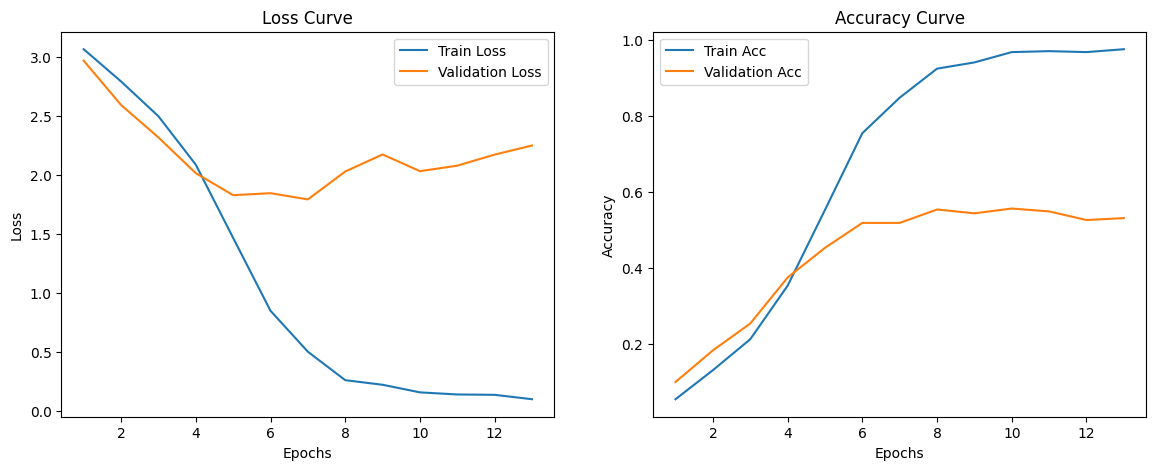

                 precision    recall  f1-score   support

         Abacha       0.46      0.69      0.55        16
        Achicha       0.62      0.77      0.69        26
          Agidi       0.55      0.73      0.63        15
           Akpu       0.62      0.88      0.73        17
            Ede       0.43      0.53      0.47        17
        Isi_Ewu       0.71      0.50      0.59        24
   Ji_Mmiri_Oku       0.53      0.77      0.63        22
         Ji_Yam       0.72      0.48      0.58        27
       Ofe_Akwu       0.53      0.48      0.50        21
      Ofe_Egusi       0.42      0.48      0.44        21
      Ofe_Nsala       0.70      0.52      0.60        27
     Ofe_Ogbono       0.20      0.10      0.13        21
        Ofe_Oha       0.58      0.41      0.48        17
      Ofe_Okazi       0.60      0.38      0.46        16
Ofe_Okwuru_Okra       0.11      0.12      0.11        16
     Ofe_Onugbu       0.78      0.78      0.78        18
     Ofe_Owerri       0.69    

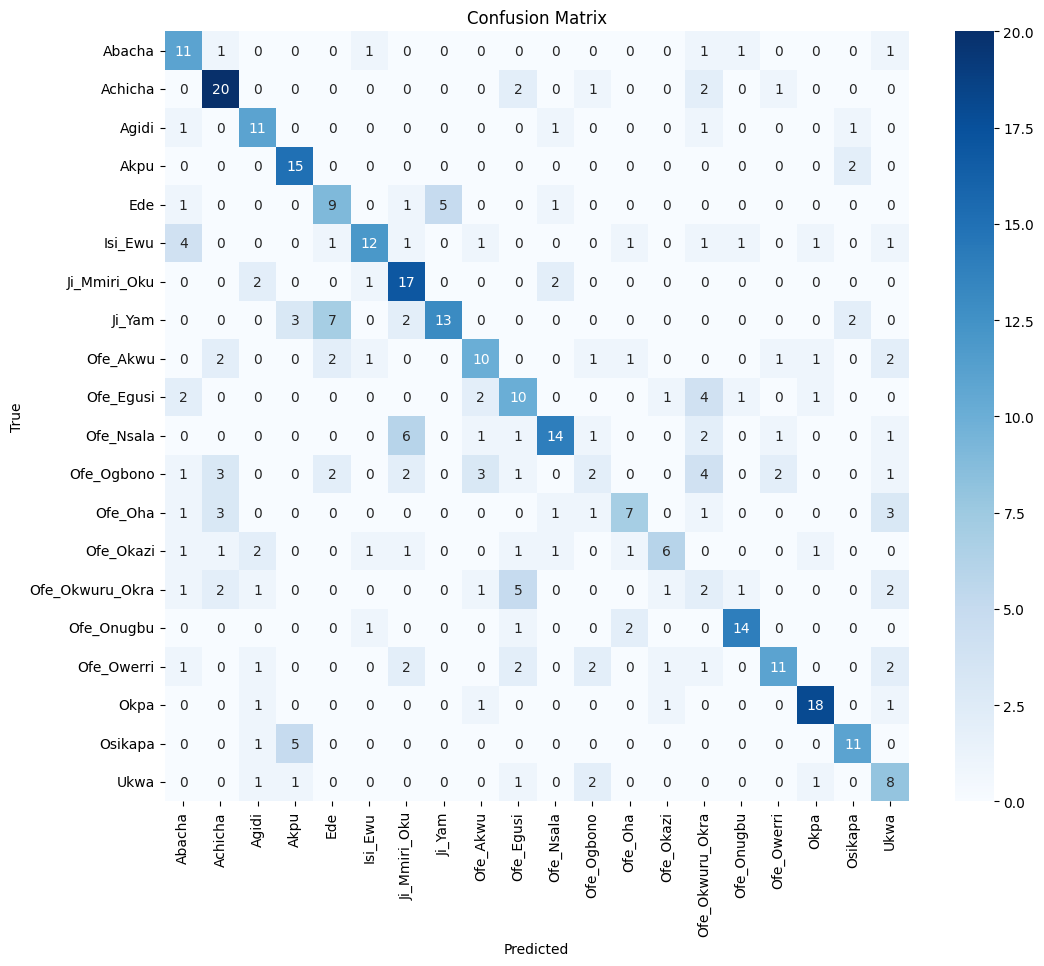

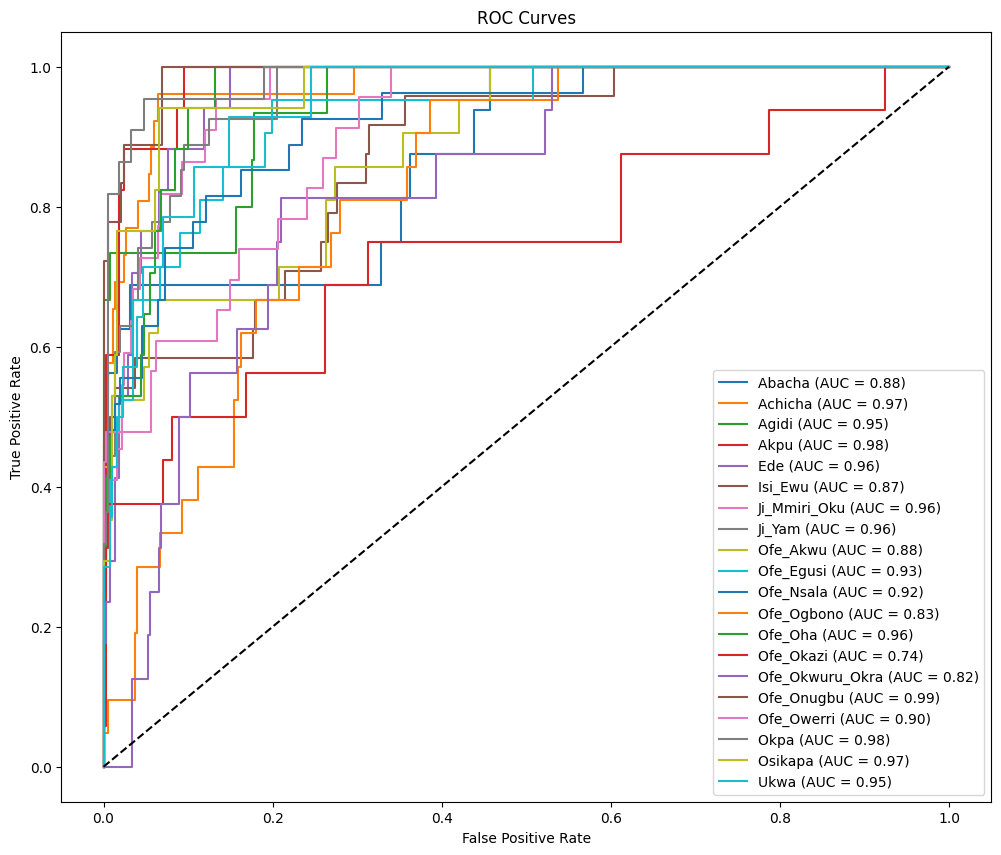

In [2]:
# ============================== SETUP ==============================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, random_split
from torch.utils.data.dataset import Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from google.colab import drive
from PIL import Image

# Mount Google Drive
drive.mount('/content/drive')

# ============================== PATHS ==============================
image_folder_path = "/content/drive/MyDrive//DatasetNew/DatasetNew/Igbo_Food_Dataset/"
csv_path = "/content/drive/MyDrive/DatasetNew/DatasetNew/Igbo_Food_Dataset.csv"
MODEL_SAVE_PATH = "/content/drive/MyDrive/igbo_food_cnn.pth"

# ============================== PARAMETERS ==============================
BATCH_SIZE = 16
IMAGE_SIZE = (224, 224)
NUM_EPOCHS = 30
LEARNING_RATE = 0.001
PATIENCE = 3  # for early stopping

# ============================== TRANSFORMS ==============================
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # 3 channels normalization
])

# ============================== LOAD DATA ==============================
dataset = ImageFolder(root=image_folder_path, transform=transform)
class_names = dataset.classes

# Split Dataset: 80% train, 20% val
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ============================== MODEL ==============================
class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CustomCNN(num_classes=len(class_names)).to(device)

# ============================== TRAINING SETUP ==============================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

def train_model(model, train_loader, val_loader, num_epochs, patience):
    best_acc = 0.0
    counter = 0
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total
        val_loss, val_acc = evaluate_model(model, val_loader, return_loss=True)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        # Early Stopping
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), MODEL_SAVE_PATH)
            print(" Saved Best Model!")
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(" Early stopping triggered!")
                break

    # Plot losses and accuracies
    plot_training(train_losses, val_losses, train_accuracies, val_accuracies)

def evaluate_model(model, val_loader, return_loss=False):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_acc = correct / total
    val_loss = running_loss / len(val_loader)
    if return_loss:
        return val_loss, val_acc
    else:
        return val_acc

def plot_training(train_losses, val_losses, train_accuracies, val_accuracies):
    epochs_range = range(1, len(train_losses)+1)

    plt.figure(figsize=(14,5))
    plt.subplot(1,2,1)
    plt.plot(epochs_range, train_losses, label="Train Loss")
    plt.plot(epochs_range, val_losses, label="Validation Loss")
    plt.legend()
    plt.title("Loss Curve")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")

    plt.subplot(1,2,2)
    plt.plot(epochs_range, train_accuracies, label="Train Acc")
    plt.plot(epochs_range, val_accuracies, label="Validation Acc")
    plt.legend()
    plt.title("Accuracy Curve")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")

    plt.show()

# ============================== TRAIN ==============================
train_model(model, train_loader, val_loader, NUM_EPOCHS, PATIENCE)

# ============================== TEST & CONFUSION MATRIX & ROC ==============================
def evaluate_and_report(model, loader):
    model.load_state_dict(torch.load(MODEL_SAVE_PATH))
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(probs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # Classification report
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12,10))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # ROC Curves
    all_labels_onehot = np.eye(len(class_names))[all_labels]
    all_probs = np.array(all_probs)
    plt.figure(figsize=(12,10))
    for i in range(len(class_names)):
        fpr, tpr, _ = roc_curve(all_labels_onehot[:,i], all_probs[:,i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title('ROC Curves')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()

evaluate_and_report(model, val_loader)

# ============================== PREDICTION FUNCTION ==============================
metadata_df = pd.read_csv(csv_path)

def predict_image(image_path):
    model.load_state_dict(torch.load(MODEL_SAVE_PATH))
    model.eval()
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image_tensor)
        probs = torch.softmax(output, dim=1)
        top_probs, top_indices = torch.topk(probs, 3)
        for i in range(3):
            idx = top_indices[0][i].item()
            prob = top_probs[0][i].item()
            class_name = class_names[idx]
            print(f"Top-{i+1} Prediction: {class_name} ({prob:.2f})")
            display_metadata(class_name)

def display_metadata(class_name):
    row = metadata_df[metadata_df['Category'] == class_name]
    if not row.empty:
        print(" Metadata:")
        print(row.iloc[0])
    else:
        print("No metadata found.")


In [3]:
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_precision_recall_curve(model, loader):
    model.load_state_dict(torch.load(MODEL_SAVE_PATH))
    model.eval()

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # Calculate Precision-Recall curve for each class
    all_labels_onehot = np.eye(len(class_names))[all_labels]
    all_probs = np.array(all_probs)

    plt.figure(figsize=(12,10))
    for i in range(len(class_names)):
        precision, recall, _ = precision_recall_curve(all_labels_onehot[:, i], all_probs[:, i])
        avg_precision = average_precision_score(all_labels_onehot[:, i], all_probs[:, i])
        plt.plot(recall, precision, label=f'{class_names[i]} (AP = {avg_precision:.2f})')

    plt.title('Precision-Recall Curves')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.show()


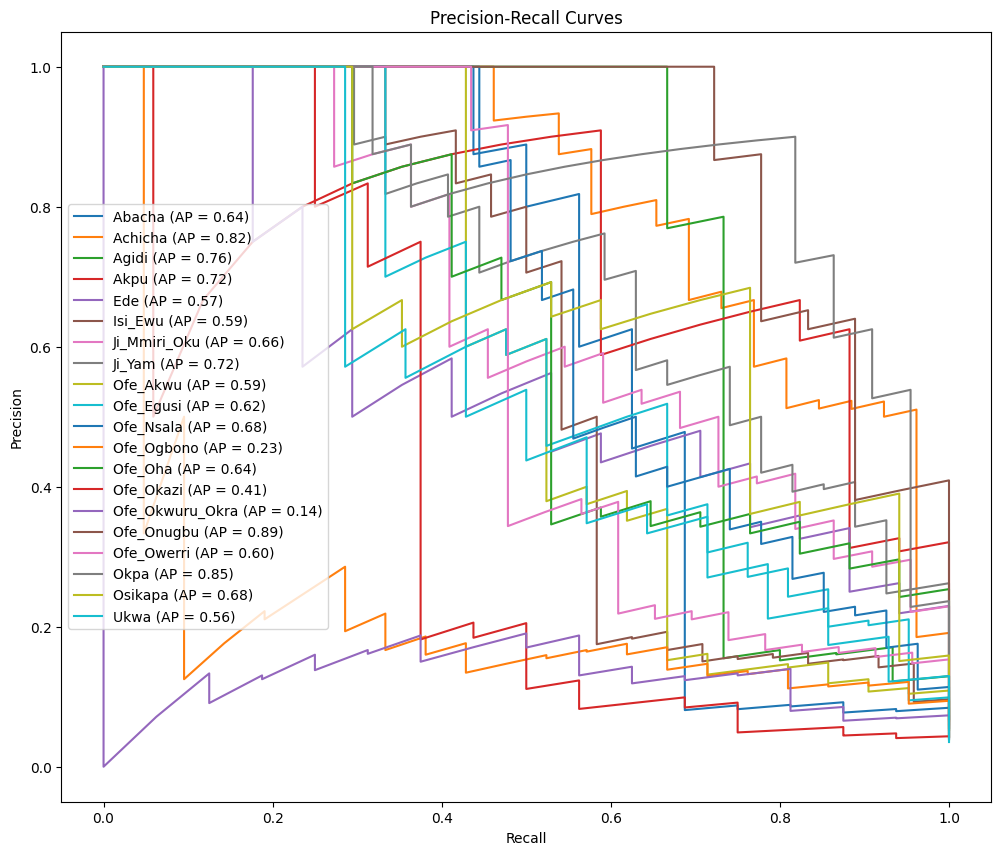

In [4]:
# Evaluate and Plot Precision-Recall Curve
plot_precision_recall_curve(model, val_loader)


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch

# Ensure inline plotting (especially for Colab)
%matplotlib inline

# Reload and prepare model if not already in memory
model = CustomCNN(num_classes=len(class_names)).to(device)
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
model.eval()

# === Grad-CAM Core Functions ===

def get_last_conv_layer(model):
    # Adjust based on your model; here we target conv3
    return model.conv3

def generate_gradcam(model, image_tensor, class_idx):
    conv_layer = get_last_conv_layer(model)
    gradients = []
    activations = []

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    def forward_hook(module, input, output):
        activations.append(output)

    forward_handle = conv_layer.register_forward_hook(forward_hook)
    backward_handle = conv_layer.register_full_backward_hook(backward_hook)  # fixed

    output = model(image_tensor)
    model.zero_grad()
    class_score = output[0, class_idx]
    class_score.backward()

    grads = gradients[0].squeeze(0).cpu().detach().numpy()  # fixed
    acts = activations[0].squeeze(0).cpu().detach().numpy()  # fixed
    weights = np.mean(grads, axis=(1, 2))

    cam = np.zeros(acts.shape[1:], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * acts[i]

    cam = np.maximum(cam, 0)
    cam = cam - np.min(cam)
    cam = cam / (np.max(cam) + 1e-8)
    cam = np.uint8(cam * 255)

    forward_handle.remove()
    backward_handle.remove()
    return cam

def show_gradcam(image_path, class_idx=None):
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    # Forward pass
    output = model(image_tensor)
    probs = torch.softmax(output, dim=1)
    predicted_class = torch.argmax(probs, dim=1).item()
    print(f"Predicted: {class_names[predicted_class]} ({probs[0][predicted_class].item():.2f})")

    class_idx = predicted_class if class_idx is None else class_idx
    cam = generate_gradcam(model, image_tensor, class_idx)

    cam_resized = Image.fromarray(cam).resize(image.size, resample=Image.BILINEAR)
    cam_resized_np = np.array(cam_resized)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(image)
    ax.imshow(cam_resized_np, cmap='jet', alpha=0.5)
    ax.set_title(f"Grad-CAM for: {class_names[class_idx]}")
    ax.axis('off')
    plt.tight_layout()
    plt.show()


Predicted: Abacha (0.83)


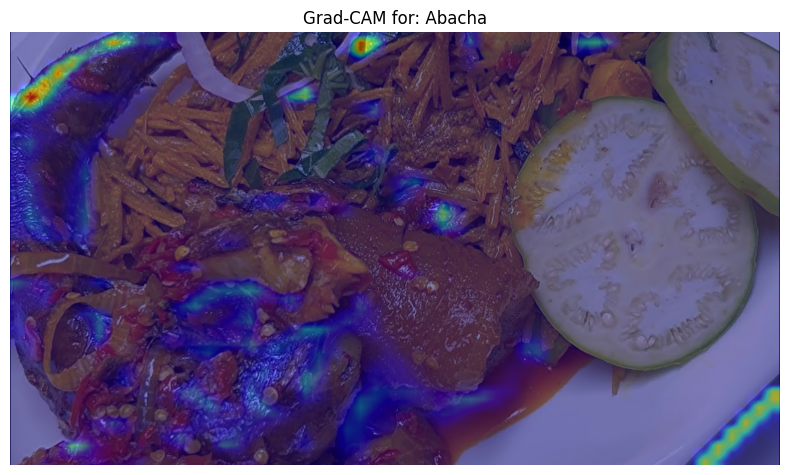

In [8]:
image_path = "/content/drive/MyDrive/DatasetNew/DatasetNew/Igbo_Food_Dataset/Abacha/Abacha_001.jpg"
show_gradcam(image_path)


Predicted: Ji_Yam (0.70)


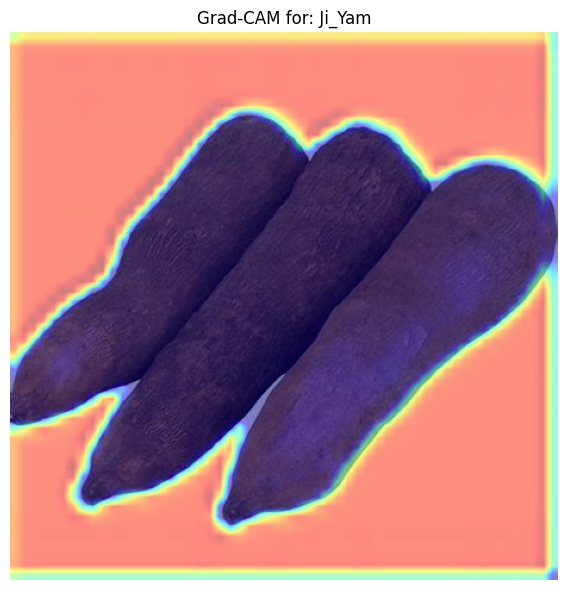

In [12]:
image_path = "/content/drive/MyDrive/DatasetNew/DatasetNew/Igbo_Food_Dataset/Ji_Yam/Ji_Yam_001.jpeg"
show_gradcam(image_path)


## Manual Testing 1

In [ ]:
# Example usage:
predict_image("/content/drive/MyDrive/DatasetNew/DatasetNew/Igbo_Food_Dataset/Ukwa/Ukwa_090.jpeg")

Top-1 Prediction: Ukwa (0.86)
📝 Metadata:
Image_Name                                                 Ukwa_073.png
Category                                                           Ukwa
Description                                   Igbo breadfruit porridge.
Ingredients                              Breadfruit, palm oil, crayfish
Preparation              Boil breadfruit, mix with palm oil and spices.
Cultural Significance                                   A festive meal.
Region                                             Southeastern Nigeria
English Name                                 Ukwa - Breadfruit Porridge
Name: 1800, dtype: object
Top-2 Prediction: Okpa (0.04)
No metadata found.
Top-3 Prediction: Abacha (0.02)
📝 Metadata:
Image_Name                                       Abacha_006.jpeg
Category                                                  Abacha
Description              African salad made from cassava flakes.
Ingredients                      Cassava, palm oil, onions, ugba
Pre

## Model 2 : EfficientNetB0

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 123MB/s] 
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_l

Epoch [1/30], Train Loss: 2.3706, Train Acc: 0.4193, Val Acc: 0.6599
 Saved Best Model!


100%|██████████| 50/50 [00:20<00:00,  2.48it/s]


Epoch [2/30], Train Loss: 1.4531, Train Acc: 0.7257, Val Acc: 0.7330
 Saved Best Model!


...

Epoch [18/30], Train Loss: 0.2966, Train Acc: 0.9445, Val Acc: 0.8237
⚠️ No Improvement. EarlyStopping Counter: 1/3


100%|██████████| 50/50 [00:19<00:00,  2.50it/s]


Epoch [19/30], Train Loss: 0.2847, Train Acc: 0.9521, Val Acc: 0.8237
⚠️ No Improvement. EarlyStopping Counter: 2/3


100%|██████████| 50/50 [00:19<00:00,  2.51it/s]


Epoch [20/30], Train Loss: 0.2821, Train Acc: 0.9458, Val Acc: 0.8262
⚠️ No Improvement. EarlyStopping Counter: 3/3
⏹️ Early stopping triggered!

Classification Report:

                 precision    recall  f1-score   support

         Abacha       0.90      0.82      0.86        22
        Achicha       1.00      0.89      0.94        18
          Agidi       0.91      0.95      0.93        21
           Akpu       0.94      0.94      0.94        16
            Ede       0.83      0.77      0.80        13
        Isi_Ewu       0.85      0.79      0.81        14
   Ji_Mmiri_Oku       0.89      0.92      0.91        26
         Ji_Yam       0.87      0.95      0.91        21
       Ofe_Akwu       0.77      0.59      0.67        17
      Ofe_Egusi       0.83      0.87      0.85        23
      Ofe_Nsala       0.79      0.83      0.81        18
     Ofe_Ogbono       0.70      0.74      0.72        19
        Ofe_Oha       0.84      0.89      0.86        18
      Ofe_Okazi       0.78     

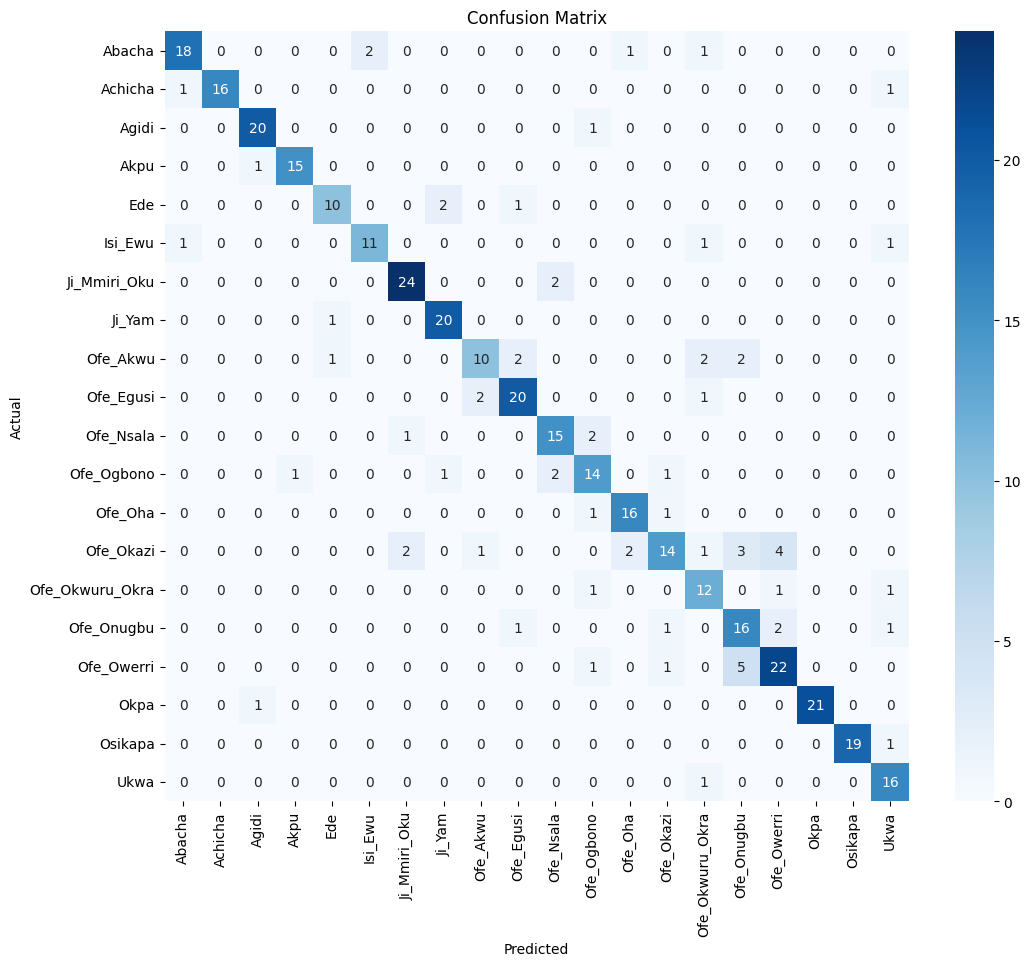

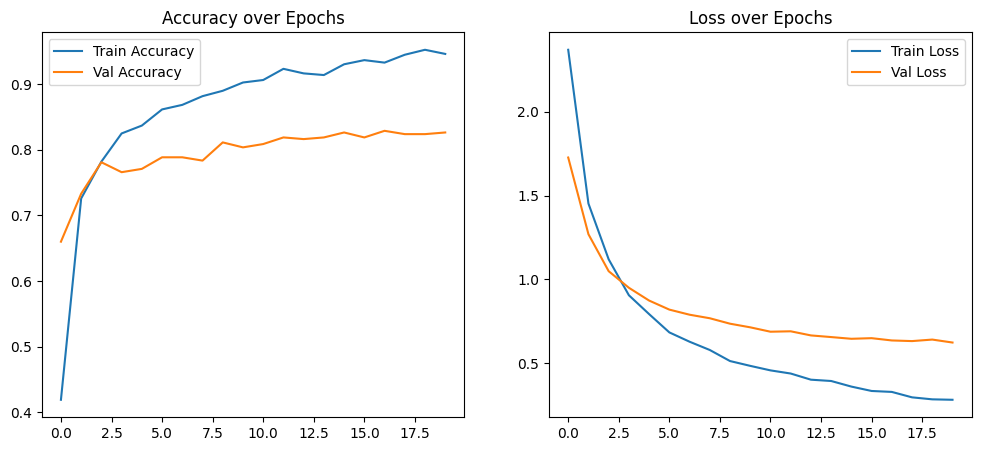

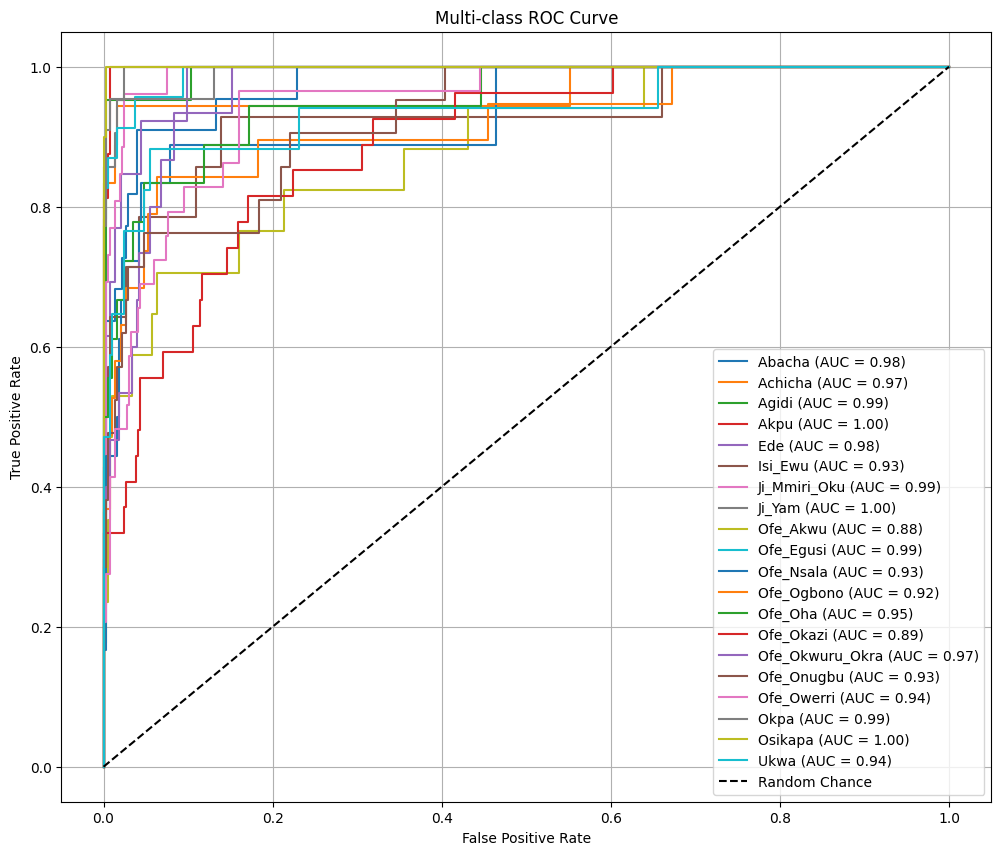

In [5]:
#  Step 1: Setup
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, random_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision.datasets import ImageFolder
from PIL import Image
from tqdm import tqdm
import time
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Paths
image_dir = "/content/drive/MyDrive/DatasetNew/DatasetNew/Igbo_Food_Dataset/"
csv_path = "/content/drive/MyDrive/DatasetNew/DatasetNew/Igbo_Food_Dataset.csv"
model_save_path = "/content/drive/MyDrive/best_model.pth"

# Metadata
metadata_df = pd.read_csv(csv_path)

#  Step 2: Device config
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

#  Step 3: Data Transforms
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

#  Step 4: Load Dataset
full_dataset = ImageFolder(root=image_dir, transform=train_transforms)
class_names = full_dataset.classes
num_classes = len(class_names)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Apply val transforms to validation dataset
val_dataset.dataset.transform = val_transforms

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

#  Step 5: Define Model - Transfer Learning (EfficientNetB0)
model = models.efficientnet_b0(pretrained=True)
for param in model.features.parameters():
    param.requires_grad = False

model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
model = model.to(device)

#  Step 6: Loss, Optimizer, Scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.3, patience=3, verbose=True)

#  Step 7: Training Loop with Early Stopping
best_val_acc = 0
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
patience = 3  #  NEW: Patience for Early Stopping
early_stopping_counter = 0

for epoch in range(30):
    model.train()
    running_loss, correct, total = 0, 0, 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * images.size(0)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # Validation
    model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            val_loss += loss.item() * images.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader.dataset)
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    scheduler.step(val_loss)

    print(f"Epoch [{epoch+1}/30], Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), model_save_path)
        print(" Saved Best Model!")
        early_stopping_counter = 0  #  reset if improvement
    else:
        early_stopping_counter += 1
        print(f"⚠️ No Improvement. EarlyStopping Counter: {early_stopping_counter}/{patience}")

        if early_stopping_counter >= patience:
            print("⏹️ Early stopping triggered!")
            break

#  Step 8: Evaluation
model.load_state_dict(torch.load(model_save_path))
model.eval()

y_true, y_pred = [], []
y_score = []

for images, labels in val_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, preds = torch.max(outputs, 1)
    y_true.extend(labels.cpu().numpy())
    y_pred.extend(preds.cpu().numpy())
    y_score.extend(outputs.detach().cpu().numpy())  #  Save raw scores for ROC

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#  Step 9: Plot Accuracy & Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Val Accuracy")
plt.title("Accuracy over Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss over Epochs")
plt.legend()
plt.show()

#  Step 9b: Plot ROC Curve  NEW
# Binarize labels for multi-class ROC
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
y_score = np.array(y_score)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(12, 10))
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.title('Multi-class ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()

#  Step 10: Prediction + CSV Metadata
def predict_image(image_path):
    model.eval()
    img = Image.open(image_path).convert('RGB')
    transform = val_transforms
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.nn.functional.softmax(output[0], dim=0)
        top3_probs, top3_indices = torch.topk(probs, 3)

    print(" Top-3 Predictions:")
    for i in range(3):
        label = class_names[top3_indices[i]]
        print(f"{label}: {top3_probs[i].item():.4f}")
        row = metadata_df[metadata_df["Category"] == label]
        if not row.empty:
            print("➤ Description:", row["Description"].values[0])
            print("➤ Ingredients:", row["Ingredients"].values[0])
            print("➤ Preparation:", row["Preparation"].values[0])
            print("➤ Cultural Significance:", row["Cultural Significance"].values[0])
            print("➤ Region:", row["Region"].values[0])
            print("➤ English Name:", row["English Name"].values[0])
            print()


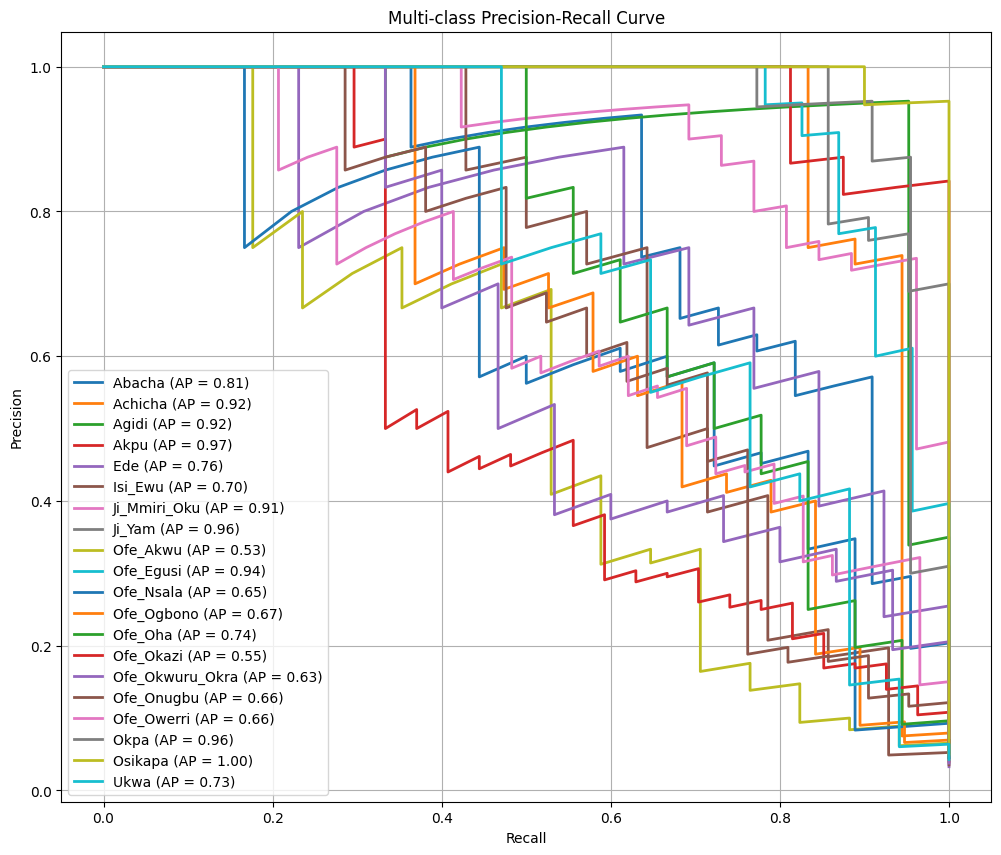

In [6]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Binarize labels for multi-class PR curve (like in ROC)
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

# Compute Precision-Recall and Average Precision for each class
precision = dict()
recall = dict()
average_precision = dict()

for i in range(num_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_true_bin[:, i], y_score[:, i])
    average_precision[i] = average_precision_score(y_true_bin[:, i], y_score[:, i])

# Plot all Precision-Recall curves
plt.figure(figsize=(12, 10))
for i in range(num_classes):
    plt.plot(recall[i], precision[i], lw=2, label=f'{class_names[i]} (AP = {average_precision[i]:.2f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Multi-class Precision-Recall Curve")
plt.legend(loc="best")
plt.grid()
plt.show()


In [ ]:
# Save the full model (not just weights)
torch.save(model, "/content/drive/MyDrive/best_model_full.pth")


## Manual Testing 1

In [ ]:
from PIL import Image
import torch
import torchvision.transforms as transforms
from torchvision import models

# Rebuild the same model architecture
model = models.efficientnet_b0(pretrained=True)
for param in model.features.parameters():
    param.requires_grad = False
model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, len(class_names))
model = model.to(device)

# Load saved weights
model.load_state_dict(torch.load(model_save_path))
model.eval()

# Define transform (must match validation)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Prediction Function
def predict_single_image(image_path):
    image = Image.open(image_path).convert('RGB')
    input_tensor = val_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.nn.functional.softmax(output, dim=1)
        top_prob, top_idx = torch.topk(probs, 1)
        predicted_label = class_names[top_idx.item()]
        confidence = top_prob.item()

    print(f"\n Top Prediction:\n{predicted_label}: {confidence:.4f}")

    # Metadata from CSV
    row = metadata_df[metadata_df['Category'] == predicted_label]
    if not row.empty:
        row = row.iloc[0]
        print(f"➤ Description: {row['Description']}")
        print(f"➤ Ingredients: {row['Ingredients']}")
        print(f"➤ Preparation: {row['Preparation']}")
        print(f"➤ Cultural Significance: {row['Cultural Significance']}")
        print(f"➤ Region: {row['Region']}")
        print(f"➤ English Name: {row['English Name']}")
    else:
        print(" No metadata found for this category.")

# 🔍 Example Test
image_path = "/content/drive/MyDrive/DatasetNew/Igbo_Food_Dataset/Ukwa/Ukwa_055.jpg"  # Replace with any test image
predict_single_image(image_path)



🔍 Top Prediction:
Ukwa: 0.9911
➤ Description: Igbo breadfruit porridge.
➤ Ingredients: Breadfruit, palm oil, crayfish
➤ Preparation: Boil breadfruit, mix with palm oil and spices.
➤ Cultural Significance: A festive meal.
➤ Region: Southeastern Nigeria
➤ English Name: Ukwa - Breadfruit Porridge


## Manual Testing 2

In [ ]:
from PIL import Image
import torch
import torchvision.transforms as transforms
from torchvision import models

# Rebuild the same model architecture
model = models.efficientnet_b0(pretrained=True)
for param in model.features.parameters():
    param.requires_grad = False
model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, len(class_names))
model = model.to(device)

# Load saved weights
model.load_state_dict(torch.load(model_save_path))
model.eval()

# Define transform (must match validation)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Prediction Function
def predict_single_image(image_path):
    image = Image.open(image_path).convert('RGB')
    input_tensor = val_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.nn.functional.softmax(output, dim=1)
        top_prob, top_idx = torch.topk(probs, 1)
        predicted_label = class_names[top_idx.item()]
        confidence = top_prob.item()

    print(f"\n Top Prediction:\n{predicted_label}: {confidence:.4f}")

    # Metadata from CSV
    row = metadata_df[metadata_df['Category'] == predicted_label]
    if not row.empty:
        row = row.iloc[0]
        print(f"➤ Description: {row['Description']}")
        print(f"➤ Ingredients: {row['Ingredients']}")
        print(f"➤ Preparation: {row['Preparation']}")
        print(f"➤ Cultural Significance: {row['Cultural Significance']}")
        print(f"➤ Region: {row['Region']}")
        print(f"➤ English Name: {row['English Name']}")
    else:
        print(" No metadata found for this category.")

# 🔍 Example Test
image_path = "/content/drive/MyDrive/DatasetNew/Igbo_Food_Dataset/Abacha/Abacha_092.jpg"  # Replace with any test image
predict_single_image(image_path)



🔍 Top Prediction:
Abacha: 0.9391
➤ Description: African salad made from cassava flakes.
➤ Ingredients: Cassava, palm oil, onions, ugba
➤ Preparation: Soak in water, mix with palm oil.
➤ Cultural Significance: Served at Igbo ceremonies.
➤ Region: Anambra
➤ English Name: Abacha - African Salad


## Model 3 : ResNet18

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using: cuda


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 189MB/s]


Epoch 1/30 - Train Acc: 0.3033, Val Acc: 0.4736
 Best model saved
Epoch 2/30 - Train Acc: 0.5725, Val Acc: 0.6121
 Best model saved
Epoch 3/30 - Train Acc: 0.6696, Val Acc: 0.6196
 Best model saved
Epoch 4/30 - Train Acc: 0.7163, Val Acc: 0.6826
 Best model saved
Epoch 5/30 - Train Acc: 0.7497, Val Acc: 0.7053
 Best model saved
Epoch 6/30 - Train Acc: 0.7623, Val Acc: 0.7003
⚠️ No improvement. Patience: 1/3
Epoch 7/30 - Train Acc: 0.7749, Val Acc: 0.7179
 Best model saved
Epoch 8/30 - Train Acc: 0.7982, Val Acc: 0.7154
⚠️ No improvement. Patience: 1/3
Epoch 9/30 - Train Acc: 0.8153, Val Acc: 0.7179
⚠️ No improvement. Patience: 2/3
Epoch 10/30 - Train Acc: 0.8108, Val Acc: 0.7280
 Best model saved
Epoch 11/30 - Train Acc: 0.8380, Val Acc: 0.7406
 Best model saved
Epoch 12/30 - Train Acc: 0.8310, Val Acc: 0.7305
⚠️ No improvement. Patience: 1/3
Epoch 13/30 - Train Acc: 0.8222, Val Acc: 0.7254
⚠️ No improvement. Patience: 2/3
Epoch 14/30 - Train Acc: 0.8424, Val Acc: 0.7280
⚠️ No improvem

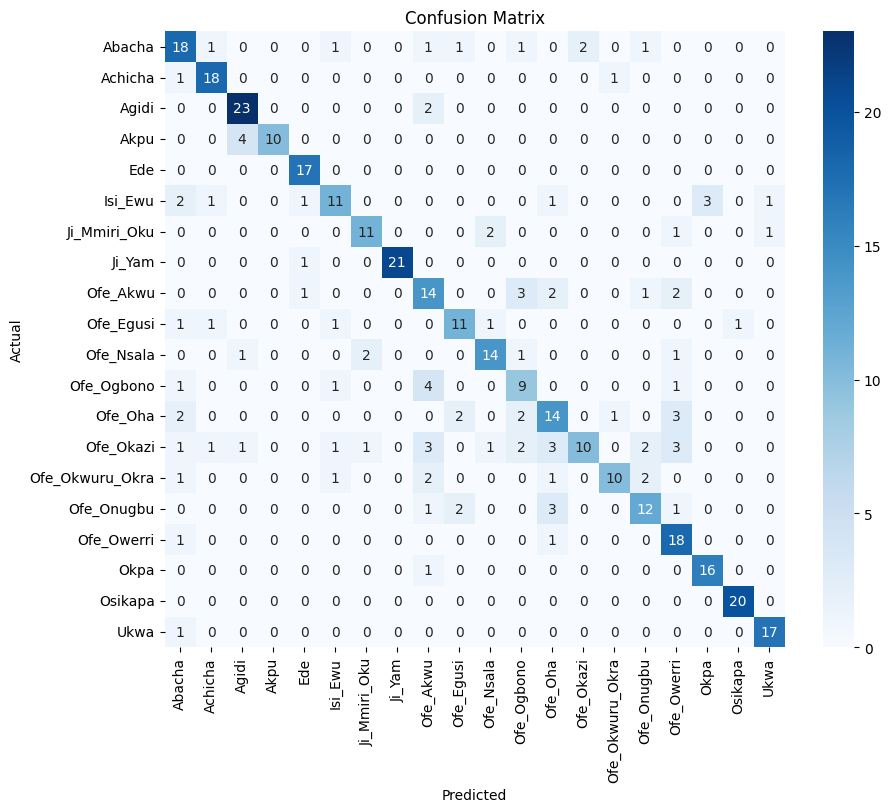

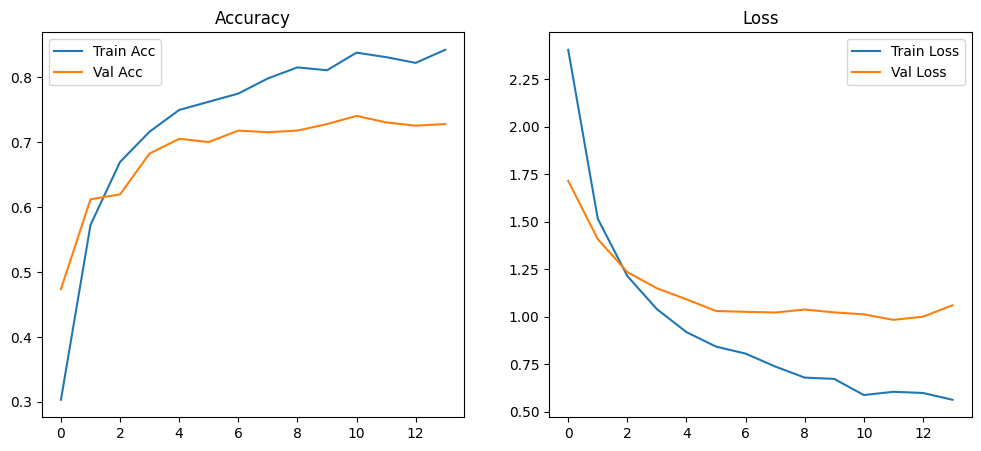

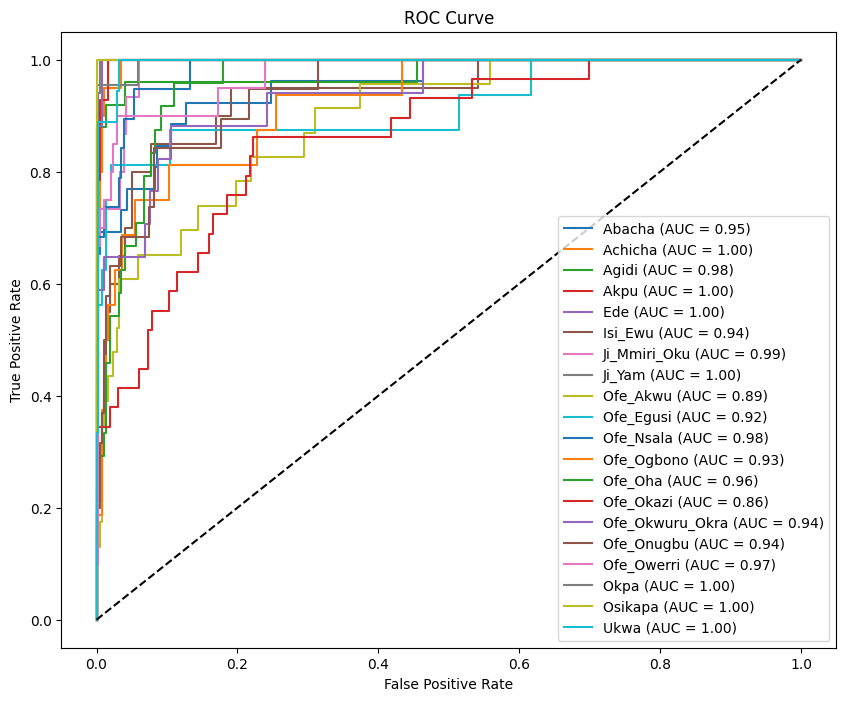

In [7]:
#  Step 1: Setup
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, random_split
from google.colab import drive
from PIL import Image
from tqdm import tqdm

# Mount Google Drive
drive.mount('/content/drive')

# Paths
image_dir = "/content/drive/MyDrive/DatasetNew/DatasetNew/Igbo_Food_Dataset/"
csv_path = "/content/drive/MyDrive/DatasetNew/DatasetNew/Igbo_Food_Dataset.csv"
model_save_path = "/content/drive/MyDrive/simple_resnet18.pth"
metadata_df = pd.read_csv(csv_path)

#  Step 2: Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

#  Step 3: Transforms (smaller image size for speed)
train_tf = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
val_tf = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

#  Step 4: Load Dataset
full_dataset = datasets.ImageFolder(root=image_dir, transform=train_tf)
class_names = full_dataset.classes
num_classes = len(class_names)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_ds, val_ds = random_split(full_dataset, [train_size, val_size])
val_ds.dataset.transform = val_tf
train_dl = DataLoader(train_ds, batch_size=16, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=16, shuffle=False)

#  Step 5: Simple ResNet18
model = models.resnet18(pretrained=True)
for param in model.parameters():
    param.requires_grad = False
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

#  Step 6: Loss & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

#  Step 7: Train Loop with Early Stopping (Patience = 3)
train_loss_hist, val_loss_hist = [], []
train_acc_hist, val_acc_hist = [], []
best_acc = 0
patience = 3
counter = 0

for epoch in range(30):  # Max 30 epochs
    model.train()
    running_loss, correct, total = 0, 0, 0
    for imgs, labels in train_dl:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    train_loss_hist.append(running_loss / len(train_dl.dataset))
    train_acc_hist.append(correct / total)

    model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_dl:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    acc = correct / total
    val_loss_hist.append(val_loss / len(val_dl.dataset))
    val_acc_hist.append(acc)

    print(f"Epoch {epoch+1}/30 - Train Acc: {train_acc_hist[-1]:.4f}, Val Acc: {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), model_save_path)
        print(" Best model saved")
        counter = 0
    else:
        counter += 1
        print(f"⚠️ No improvement. Patience: {counter}/{patience}")
        if counter >= patience:
            print(" Early stopping triggered.")
            break

#  Step 8: Evaluation
model.load_state_dict(torch.load(model_save_path))
model.eval()

y_true, y_pred, y_score = [], [], []
with torch.no_grad():
    for imgs, labels in val_dl:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(torch.argmax(probs, 1).cpu().numpy())
        y_score.extend(probs.cpu().numpy())

#  Step 9: Metrics & Plots
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_acc_hist, label="Train Acc")
plt.plot(val_acc_hist, label="Val Acc")
plt.legend(); plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(train_loss_hist, label="Train Loss")
plt.plot(val_loss_hist, label="Val Loss")
plt.legend(); plt.title("Loss")
plt.show()

y_true_bin = label_binarize(y_true, classes=range(num_classes))
fpr, tpr, roc_auc = {}, {}, {}
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], np.array(y_score)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

#  Step 10: Predict + Metadata
def predict_image(img_path):
    model.eval()
    img = Image.open(img_path).convert('RGB')
    img_tensor = val_tf(img).unsqueeze(0).to(device)
    with torch.no_grad():
        out = model(img_tensor)
        probs = torch.softmax(out[0], dim=0)
        top3_probs, top3_idx = torch.topk(probs, 3)
    print(" Top-3 Predictions:")
    for i in range(3):
        label = class_names[top3_idx[i]]
        print(f"{label}: {top3_probs[i].item():.4f}")
        row = metadata_df[metadata_df["Category"] == label]
        if not row.empty:
            print("➤ Description:", row["Description"].values[0])
            print("➤ Ingredients:", row["Ingredients"].values[0])
            print("➤ Preparation:", row["Preparation"].values[0])
            print("➤ Cultural Significance:", row["Cultural Significance"].values[0])
            print("➤ Region:", row["Region"].values[0])
            print("➤ English Name:", row["English Name"].values[0])
            print()


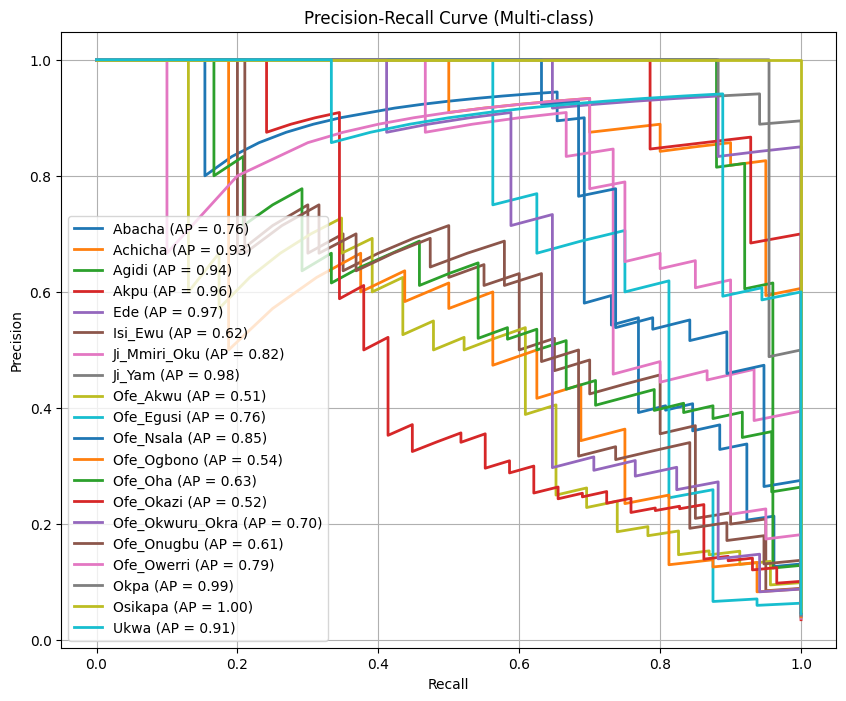

In [8]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Binarize true labels for multi-class Precision-Recall computation
y_true_bin = label_binarize(y_true, classes=range(num_classes))
y_score_array = np.array(y_score)

# Compute precision-recall and average precision for each class
precision = dict()
recall = dict()
average_precision = dict()

for i in range(num_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_true_bin[:, i], y_score_array[:, i])
    average_precision[i] = average_precision_score(y_true_bin[:, i], y_score_array[:, i])

# Plot all PR curves
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    plt.plot(recall[i], precision[i], lw=2, label=f'{class_names[i]} (AP = {average_precision[i]:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Multi-class)')
plt.legend(loc='best')
plt.grid()
plt.show()
